In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from modulos.gerais import preparar_breast_cancer, exibir_resultado, exibir_relatorio_de_classificacao
from modulos.arvore_de_decisao import executar_arvore_de_decisao, exibir_regras_da_arvore_de_decisao, gerar_grafico_da_arvore_de_decisao


In [3]:
# Importação e exploração dos dados
breast_cancer = load_breast_cancer()
X, y, feature_names, target_names = preparar_breast_cancer(breast_cancer)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


In [5]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Breast Cancer
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.9006
Precisão:  0.9000
Revocação: 0.8860
F1-Score:  0.8921




In [6]:
# Exibição das Regras Geradas
exibir_regras_da_arvore_de_decisao(clf, feature_names)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- worst area <= 884.55
|   |--- worst concave points <= 0.18
|   |   |--- mean concave points <= 0.05
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.05
|   |   |   |--- class: 1
|   |--- worst concave points >  0.18
|   |   |--- class: 0
|--- worst area >  884.55
|   |--- worst smoothness <= 0.09
|   |   |--- class: 1
|   |--- worst smoothness >  0.09
|   |   |--- texture error <= 0.45
|   |   |   |--- class: 0
|   |   |--- texture error >  0.45
|   |   |   |--- class: 0



In [7]:
# Exibição do relatório de classificação da Árvore de Decisão com Breast Cancer
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, target_names)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

   malignant       0.90      0.83      0.86        64
      benign       0.90      0.94      0.92       107

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



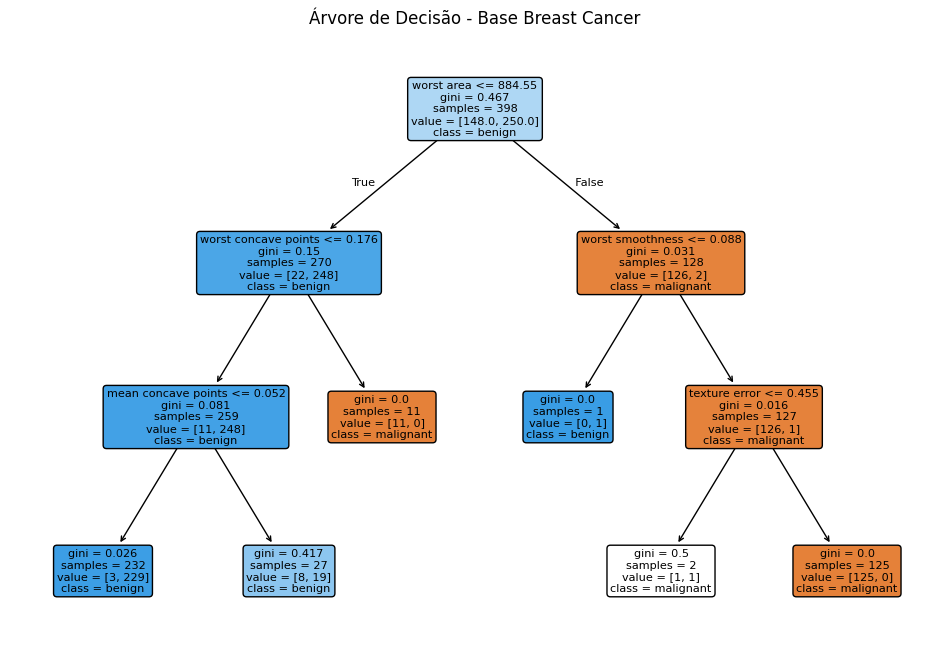

In [8]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Breast Cancer')